<a href="https://colab.research.google.com/github/Churrascooo/Practica-1/blob/main/CODIGOFINAL/Fase5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explicación de la fase

La fase 5 consiste en la creación de los modelos de Machine Learning. Se usarán 3 modelos para predecir el evento coronario agudo y mortalidad. La idea de usar diferentes modelos es para comparar y saber con precisión que tal funcionan.
Los modelos que se utilizarán son:
- **Random Forest**
- **CatBoost**
- **Híbrido entre TF-IDF + MLP**

A su vez, es importante señalar que **CatBoost** se eligió como modelo principal porque está especialmente diseñado para datos clínicos tabulares complejos, capturando mejor interacciones no lineales que Random Forest. A diferencia de modelos basados en texto, aprovecha directamente la información clínica estructurada y es más estable frente a un fuerte desbalance de clases. Es por ello que resulta especialmente adecuado para datos reales de historias clínicas electrónicas.

# Importación y cargado de herramientas necesarias

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Importación de Random Forest
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#Instalación e importación de CatBoost
!pip -q install catboost
from catboost import CatBoostClassifier

In [ ]:
#Importación de herramientas TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#Importación de MLP y herramientas
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#Importación de parquets a utilizar
OUT_DIR = "/content/drive/MyDrive/mimic_outputs"

patient_history = pd.read_parquet(
    os.path.join(OUT_DIR, "patient_history.parquet")
)

patient_comorb = pd.read_parquet(
    os.path.join(OUT_DIR, "patient_comorb_top5.parquet")
)

outcome_coronary = pd.read_parquet(
    os.path.join(OUT_DIR, "outcome_coronary_acute.parquet")
)

notes = pd.read_parquet(
    os.path.join(OUT_DIR, "patient_notes_first_single.parquet")
)

outcome_death_acs = pd.read_parquet(
    os.path.join(OUT_DIR, "outcome_death_coronary_acute.parquet")
)

print(patient_history.shape)
print(patient_comorb.shape)
print(outcome_coronary.shape)
print(notes.shape)
print(outcome_death_acs.shape)

(111122, 18)
(111122, 6)
(111122, 2)
(111122, 3)
(111122, 2)


In [ ]:
#Dataset final que se usa para entrenar a los modelos
df_ml = (
    patient_history
    .merge(patient_comorb, on="subject_id", how="left", validate="one_to_one")
    .merge(outcome_coronary, on="subject_id", how="left", validate="one_to_one")
)

print(df_ml.shape)
df_ml.head()

(111122, 24)


,subject_id,hadm_id,admittime,dischtime,deathtime,hospital_expire_flag,gender,anchor_age,anchor_year,admit_year,...,last_drug_time_48h,icu_any,n_icu_stays,icu_los_days,4019,E785,I10,K219,Z87891,target_coronary_acute
0,10000084,29888819,2160-12-28 05:11:00,2160-12-28 16:07:00,NaT,0,M,72,2160,2160,...,NaT,0,0,0.0,0,1,0,0,0,0
1,10000161,22148160,2163-08-20 01:42:00,2163-08-20 16:33:00,NaT,0,M,60,2163,2163,...,NaT,0,0,0.0,0,0,0,0,0,0
2,10000635,20642640,2143-12-23 14:55:00,2143-12-24 12:52:00,NaT,0,F,74,2136,2143,...,NaT,0,0,0.0,0,0,1,0,0,0
3,10000690,26146595,2152-01-28 23:40:00,2152-01-30 15:56:00,NaT,0,F,86,2150,2152,...,2152-01-30 14:00:00,0,0,0.0,0,0,0,0,0,0
4,10000764,27897940,2132-10-14 23:31:00,2132-10-19 16:30:00,NaT,0,M,86,2132,2132,...,2132-10-16 20:00:00,0,0,0.0,1,0,0,0,0,1


In [ ]:
#Nombre del target (para reutilizar)
TARGET_COL = "target_coronary_acute"

#Target binario
y = df_ml[TARGET_COL].astype(int)

#Columnas que no deben entrar a ningún modelo
DROP_COLS_BASE = [
    "subject_id",
    "hadm_id",
    "admittime",
    "dischtime",
    "deathtime",
    "hospital_expire_flag",
    TARGET_COL
]

#Features base (comunes a todos los modelos)
X_base = df_ml.drop(
    columns=[c for c in DROP_COLS_BASE if c in df_ml.columns]
)

#Resultados
print("X_base:", X_base.shape)
print("y:", y.shape)
print("Prevalencia del target:")
y.value_counts(normalize=True)

X_base: (111122, 17)
y: (111122,)
Prevalencia del target:


,proportion
target_coronary_acute,
0,0.927008
1,0.072992


# Preparación para Random Forest - Evento coronario agudo

In [ ]:
#Inicialización de X para Random Forest
X = X_base.copy()

print(X.shape, y.shape)
X.dtypes

(111122, 17) (111122,)


,0
gender,object
anchor_age,int64
anchor_year,int64
admit_year,int32
age_at_admit,int64
n_unique_dx,int64
n_unique_drugs_48h,int64
last_drug_48h,object
last_drug_time_48h,datetime64[ns]
icu_any,int64


In [ ]:
#Se eliminan las columnas no aptas para Random Forest
drop_rf = [
    "last_drug_48h",
    "last_drug_time_48h"
]

X = X.drop(columns=[c for c in drop_rf if c in X.columns])

#Convertir gender a binaria porque Random Forest no acepta object
if "gender" in X.columns:
    X["gender"] = X["gender"].map({"M": 1, "F": 0}).fillna(0).astype(int)

#Se aseguran que no queden NaN
X = X.fillna(0)

#Ver resultados
print(X.dtypes)

gender                  int64
anchor_age              int64
anchor_year             int64
admit_year              int32
age_at_admit            int64
n_unique_dx             int64
n_unique_drugs_48h      int64
icu_any                 int64
n_icu_stays             int64
icu_los_days          float64
4019                    int64
E785                    int64
I10                     int64
K219                    int64
Z87891                  int64
dtype: object


# Random Forest - Evento coronario agudo

In [ ]:
#Entreno y evaluación del modelo Random Forest

#Validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Se inicializan las métricas
auc_scores = []
sens_scores = []
spec_scores = []
ppv_scores  = []

#Bucle para entrenar por fold. En cada fold se separa train/test y se entrena un Random Forest balanceado
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"Fold {fold}")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=50,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced"
    )

    rf.fit(X_train, y_train)

    #Predicción y métricas
    y_proba = rf.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    #AUC
    auc_scores.append(roc_auc_score(y_test, y_proba))

    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    #Métricas clínicas
    sens_scores.append(tp / (tp + fn))   #Sensibilidad
    spec_scores.append(tn / (tn + fp))   #Especificidad
    ppv_scores.append(tp / (tp + fp))    #Precision / PPV

    if fold == skf.n_splits:
        y_test_rf  = y_test.values
        y_proba_rf = y_proba

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [ ]:
#Resultados finales
print("\nRandom Forest (5-Fold CV)")
print(f"AUC-ROC       : {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")
print(f"Sensitivity   : {np.mean(sens_scores):.3f}")
print(f"Specificity   : {np.mean(spec_scores):.3f}")
print(f"PPV           : {np.mean(ppv_scores):.3f}")

#Guardar resultados para gráficos de Results
auc_rf  = auc_scores.copy()
sens_rf = sens_scores.copy()
spec_rf = spec_scores.copy()
ppv_rf  = ppv_scores.copy()


Random Forest (5-Fold CV)
AUC-ROC       : 0.766 ± 0.004
Sensitivity   : 0.649
Specificity   : 0.740
PPV           : 0.164


# Preparación para Catboost - Evento coronario agudo

In [ ]:
#Inicialización de X para CatBoost
X = X_base.copy()

#Eliminar columnas no aptas para CatBoost
drop_cb = ["last_drug_time_48h"]
X = X.drop(columns=[c for c in drop_cb if c in X.columns])

In [ ]:
#Identifica columnas categóricas de manera automática
cat_features = X.select_dtypes(include=["object"]).columns.tolist()
print("Columnas categóricas:", cat_features)

Columnas categóricas: ['gender', 'last_drug_48h']


In [ ]:
#Rellena categóricas
X[cat_features] = X[cat_features].fillna("UNKNOWN")

#Rellena numéricas
num_cols = X.columns.difference(cat_features)
X[num_cols] = X[num_cols].fillna(0)

#Resultados
print(X.dtypes)

gender                 object
anchor_age              int64
anchor_year             int64
admit_year              int32
age_at_admit            int64
n_unique_dx             int64
n_unique_drugs_48h      int64
last_drug_48h          object
icu_any                 int64
n_icu_stays             int64
icu_los_days          float64
4019                    int64
E785                    int64
I10                     int64
K219                    int64
Z87891                  int64
dtype: object


# Catboost - Evento coronario agudo

In [ ]:
#Validación Cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Se inicializan las métricas
auc_scores = []
sens_scores = []
spec_scores = []
ppv_scores  = []

#Bucle para entrenar por fold
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"Fold {fold}")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    #Definición del modelo
    cb = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=[1, (y == 0).sum() / (y == 1).sum()],
        random_seed=42,
        verbose=False
    )

    #Entrenamiento del modelo
    cb.fit(
        X_train, y_train,
        cat_features=cat_features
    )

    #Predicción y métricas
    y_proba = cb.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    #AUC
    auc_scores.append(roc_auc_score(y_test, y_proba))

    #Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    #Métricas clínicas
    sens_scores.append(tp / (tp + fn))
    spec_scores.append(tn / (tn + fp))
    ppv_scores.append(tp / (tp + fp))

    if fold == skf.n_splits:
        y_test_cb  = y_test.values
        y_proba_cb = y_proba

        #Guardar modelo final para interpretabilidad
        cb_final = cb
        feature_names_cb = X.columns.tolist()

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [ ]:
#Resultados finales
print("\nCatBoost (5-Fold CV)")
print(f"AUC-ROC       : {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")
print(f"Sensitivity   : {np.mean(sens_scores):.3f}")
print(f"Specificity   : {np.mean(spec_scores):.3f}")
print(f"PPV           : {np.mean(ppv_scores):.3f}")

auc_cb  = auc_scores.copy()
sens_cb = sens_scores.copy()
spec_cb = spec_scores.copy()
ppv_cb  = ppv_scores.copy()


CatBoost (5-Fold CV)
AUC-ROC       : 0.796 ± 0.005
Sensitivity   : 0.734
Specificity   : 0.707
PPV           : 0.165


# Preparación TF-IDF - Evento coronario agudo

In [ ]:
#Se seleccionas las columnas relevantes para el dataset
df_text_acs = (
    df_ml[["subject_id", "target_coronary_acute"]]
    .merge(
        notes[["subject_id", "notes_first_single"]], #Se añaden las notas clínicas para el texto asociado
        on="subject_id",                             #a cada paciente
        how="left",
        validate="one_to_one"
    )
)

#Resultados para ver que todo esté ok
print(df_text_acs.shape)

(111122, 3)


In [ ]:
#Target
y_acs = df_text_acs["target_coronary_acute"].astype(int) #Se convierte a entero para asegurar que sea compatible con el modelo

X_text_acs = (
    df_text_acs["notes_first_single"]
    .fillna("") #Se rellenan valores nulos con string vacíos
    .astype(str) #Se asegura que todos los valores sean string
)

#Resultados para ver que todo esté ok
print("Pacientes totales:", len(X_text_acs))
print("Pacientes con nota:", (X_text_acs.str.len() > 0).sum())

Pacientes totales: 111122
Pacientes con nota: 63763


In [ ]:
#Se incia el vectorizados TF-IDF para transformar el texto de las notas a variables numéricas
tfidf_acs = TfidfVectorizer(
    max_features=30000, #Se limita el número máximo de términos para controlar memoria
    ngram_range=(1, 2), #Se incluyen unigramas y bigramas para capturar texto local
    min_df=5, #Se ignoran los términos que sean raros (aparecen en menos de 5 documentos)
    max_df=0.9, #Se destarcan los términos demasiado frecuentes, ya que son poco informativos
    stop_words="english" #Se eliminan las stopwords en inglés ya que las notas están en ese idioma
)

#Se ajusta el vectorizados y se transforma el texto
X_tfidf_acs = tfidf_acs.fit_transform(X_text_acs)

#Ver resultados
print(X_tfidf_acs.shape)

(111122, 30000)


In [ ]:
#Se inicia truncatedSVD para reducir dimensionalidad del TF-IDF
svd = TruncatedSVD(
    n_components=300, #Número de componentes
    random_state=42 #Se garantiza la reproductibilidad de los resultados
)

#Se ajusta el modelo SVD y se proyecta el TF-IDF a un espacio menor
X_text_svd = svd.fit_transform(X_tfidf_acs)

#Ver resultados para verificar la dimensionalidad
print(X_text_svd.shape)

(111122, 300)


# Preparación MLP - Evento coronario agudo

In [ ]:
#Se construye el modelo MLP para clasificación binaria
def build_mlp(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)), #Capa de entrada que define la dimensionalidad del vector de features
        Dense(256, activation="relu"), #Se usan 256 neuronas para capturar interacciones complejas
        Dropout(0.3), #Esto es para reducir el overfitting
        Dense(64, activation="relu"), #Segunda capa donde se usan menos neuronas para forzar la comprensión de la información
        Dropout(0.3), #Dropout adicional para regularización
        Dense(1, activation="sigmoid") #Capa de salida donde se usa 1 neurona porque es clasificación binaria
    ])                                 #Sigmoid produce una probabilidad en el rango 0, 1

    #Se compila el modelo
    model.compile( #Se usa Adam ya que es un optimizador robusto y eficiente para redes
        optimizer=Adam(learning_rate=1e-3), #Se usa learning_rate=1e-3 ya que es un valor estándar que suele funcionar bien
        loss="binary_crossentropy" #Es la función de pérdida adecuada para clasificación binaria
    )

    #Se devuelve el modelo listo para entrenar
    return model

# TF-IDF + MLP - Evento coronario agudo

In [ ]:
#Se inicializa StratifiedKFold para hacer validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#n_splits=5 son los números de pliegues en la validación cruzada (5 pliegues)
#shuffle=True baraja los datos antes de dividir en pliegues, para así asegurar aleatoriedad
#random_state=42 se usa para fijar la semilla para reproductibilidad de los resultados

#Se inician las métricas vacías
auc_scores = []
sens_scores = []
spec_scores = []
ppv_scores  = []

In [ ]:
#Se comienza la validación cruzada estratificada
for fold, (train_idx, test_idx) in enumerate(skf.split(X_text_svd, y), 1):
    print(f"\nFold {fold}")

    #Se dividen los datos en conjuntos de entrenamiento y prueba
    X_train = X_text_svd[train_idx]
    X_test  = X_text_svd[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    #Se crea el modelo MLP para este pliegue
    model = build_mlp(input_dim=X_train.shape[1])

    #Se configura EarlyStopping para evitar el sobreajuste
    early_stop = EarlyStopping(
        monitor="val_loss", #Se monitorea la pérdida en el conjunto de validación
        patience=3, #Si no mejora en 3 épocas, se para el entrenamiento
        restore_best_weights=True #Se restauran los mejores pesos cuando se detiene
    )

    #Se entrena el modelo con la validación interna (10% de los datos de entrenamiento)
    model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=30,
        batch_size=256,
        callbacks=[early_stop],
        verbose=0
    )

    #Se hacen las predicciones de probabilidad sobre el conjunto de prueba
    y_proba = model.predict(X_test).ravel() #Se aplana la salida a 1D
    y_pred  = (y_proba >= 0.5).astype(int) #Se convierte la probabilidad a clases binarias

    #Se calcula el AUC para evaluar la capacidad discriminatoria del modelo
    auc_scores.append(roc_auc_score(y_test, y_proba))

    #Se calcula la matriz de confusión para obtener las métricas de rendimiento
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    #Esto es la sensibilidad que sirve para ver la tasa de verdaderos positivos
    sens_scores.append(tp / (tp + fn))

    #Esta es la especificidad que sirve para ver la tasa de verdaderos negativos
    spec_scores.append(tn / (tn + fp))

    #Este es el PPV, el cual entrega precisión y sirve para ver la tasa de aciertos en las predicciones positivas
    ppv_scores.append(tp / (tp + fp))

    if fold == skf.n_splits:
        y_test_mlp  = y_test.values
        y_proba_mlp = y_proba


Fold 1
695/695 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Fold 2
695/695 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Fold 3
695/695 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Fold 4
695/695 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Fold 5
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [ ]:
#Resultados
print("\nTF-IDF + MLP (5-Fold CV)")
print(f"AUC-ROC       : {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")
print(f"Sensitivity   : {np.mean(sens_scores):.3f}")
print(f"Specificity   : {np.mean(spec_scores):.3f}")
print(f"PPV           : {np.mean(ppv_scores):.3f}")

auc_mlp  = auc_scores.copy()
sens_mlp = sens_scores.copy()
spec_mlp = spec_scores.copy()
ppv_mlp  = ppv_scores.copy()


TF-IDF + MLP (5-Fold CV)
AUC-ROC       : 0.694 ± 0.006
Sensitivity   : 0.026
Specificity   : 0.999
PPV           : 0.636


# _______________________________________________________________________




# Preparación para Random Forest - Mortalidad por evento coronario agudo

In [ ]:
#Definición del target
TARGET_COL = "target_death_coronary_acute"

#Merge del outcome de mortalidad
df_ml_death = (
    patient_history
    .merge(patient_comorb, on="subject_id", how="left", validate="one_to_one")
    .merge(outcome_death_acs, on="subject_id", how="left", validate="one_to_one")
)

print(df_ml_death.shape)

(111122, 24)


In [ ]:
#Target binario
y = df_ml_death[TARGET_COL].astype(int)

#Columnas que no deben entrar al modelo
DROP_COLS_BASE = [
    "subject_id",
    "hadm_id",
    "admittime",
    "dischtime",
    "deathtime",
    "hospital_expire_flag",
    TARGET_COL
]

#Features base
X_base = df_ml_death.drop(
    columns=[c for c in DROP_COLS_BASE if c in df_ml_death.columns]
)

print("X_base:", X_base.shape)
print("y:", y.shape)
print("Prevalencia del target:")
y.value_counts(normalize=True)

X_base: (111122, 17)
y: (111122,)
Prevalencia del target:


,proportion
target_death_coronary_acute,
0,0.985457
1,0.014543


In [ ]:
#Inicialización de X para Random Forest
X = X_base.copy()

print(X.shape, y.shape)
X.dtypes

(111122, 17) (111122,)


,0
gender,object
anchor_age,int64
anchor_year,int64
admit_year,int32
age_at_admit,int64
n_unique_dx,int64
n_unique_drugs_48h,int64
last_drug_48h,object
last_drug_time_48h,datetime64[ns]
icu_any,int64


In [ ]:
#Eliminación de columnas no aptas para Random Forest
drop_rf = [
    "last_drug_48h",
    "last_drug_time_48h"
]

X = X.drop(columns=[c for c in drop_rf if c in X.columns])

In [ ]:
#Conversión de gender a binaria
if "gender" in X.columns:
    X["gender"] = (
        X["gender"]
        .map({"M": 1, "F": 0})
        .fillna(0)
        .astype(int)
    )

In [ ]:
#Relleno de valores faltantes
X = X.fillna(0)

#Verificación final
print(X.dtypes)

gender                  int64
anchor_age              int64
anchor_year             int64
admit_year              int32
age_at_admit            int64
n_unique_dx             int64
n_unique_drugs_48h      int64
icu_any                 int64
n_icu_stays             int64
icu_los_days          float64
4019                    int64
E785                    int64
I10                     int64
K219                    int64
Z87891                  int64
dtype: object


# Random Forest - Mortalidad por evento coronario agudo

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

auc_scores  = []
sens_scores = []
spec_scores = []
ppv_scores  = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"Fold {fold}")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=50,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced"
    )

    rf.fit(X_train, y_train)

    #Predicciones
    y_proba = rf.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    #AUC
    auc_scores.append(
        roc_auc_score(y_test, y_proba)
    )

    #Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred
    ).ravel()

    #Métricas clínicas
    sens_scores.append(tp / (tp + fn))
    spec_scores.append(tn / (tn + fp))
    ppv_scores.append(tp / (tp + fp))

    #Guardar último fold para ROC
    if fold == skf.n_splits:
        y_test_rf_death  = y_test.values
        y_proba_rf_death = y_proba

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [ ]:
#Resultados finales
print("\nRandom Forest – Mortalidad por Evento Coronario Agudo (5-Fold CV)")
print(f"AUC-ROC       : {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")
print(f"Sensitivity   : {np.mean(sens_scores):.3f}")
print(f"Specificity   : {np.mean(spec_scores):.3f}")
print(f"PPV           : {np.mean(ppv_scores):.3f}")

#Guardar métricas para gráficos
auc_rf_death  = auc_scores.copy()
sens_rf_death = sens_scores.copy()
spec_rf_death = spec_scores.copy()
ppv_rf_death  = ppv_scores.copy()


Random Forest – Mortalidad por Evento Coronario Agudo (5-Fold CV)
AUC-ROC       : 0.905 ± 0.007
Sensitivity   : 0.749
Specificity   : 0.878
PPV           : 0.083


# Preparación para Catboost - Mortalidad por evento coronario agudo

In [ ]:
#Definición del target
TARGET_COL = "target_death_coronary_acute"

#Merge del outcome de mortalidad
df_ml_death = (
    patient_history
    .merge(patient_comorb, on="subject_id", how="left", validate="one_to_one")
    .merge(outcome_death_acs, on="subject_id", how="left", validate="one_to_one")
)

print(df_ml_death.shape)

(111122, 24)


In [ ]:
#Target binario
y = df_ml_death[TARGET_COL].astype(int)

#Columnas que no deben entrar al modelo
DROP_COLS_BASE = [
    "subject_id",
    "hadm_id",
    "admittime",
    "dischtime",
    "deathtime",
    "hospital_expire_flag",
    TARGET_COL
]

#Features base
X_base = df_ml_death.drop(
    columns=[c for c in DROP_COLS_BASE if c in df_ml_death.columns]
)

print("X_base:", X_base.shape)
print("y:", y.shape)
print("Prevalencia del target:")
y.value_counts(normalize=True)

X_base: (111122, 17)
y: (111122,)
Prevalencia del target:


,proportion
target_death_coronary_acute,
0,0.985457
1,0.014543


In [ ]:
#Inicialización de X para CatBoost
X = X_base.copy()

In [ ]:
#Eliminación de columnas no aptas para CatBoost
drop_cb = ["last_drug_time_48h"]
X = X.drop(columns=[c for c in drop_cb if c in X.columns])

In [ ]:
#Identificación automática de columnas categóricas
cat_features = X.select_dtypes(include=["object"]).columns.tolist()
print("Columnas categóricas:", cat_features)

Columnas categóricas: ['gender', 'last_drug_48h']


In [ ]:
#Relleno de valores faltantes
#Categóricas
X[cat_features] = X[cat_features].fillna("UNKNOWN")

#Numéricas
num_cols = X.columns.difference(cat_features)
X[num_cols] = X[num_cols].fillna(0)

#Verificación final
print(X.dtypes)

gender                 object
anchor_age              int64
anchor_year             int64
admit_year              int32
age_at_admit            int64
n_unique_dx             int64
n_unique_drugs_48h      int64
last_drug_48h          object
icu_any                 int64
n_icu_stays             int64
icu_los_days          float64
4019                    int64
E785                    int64
I10                     int64
K219                    int64
Z87891                  int64
dtype: object


# Catboost - Mortalidad por evento coronario agudo

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

auc_scores  = []
sens_scores = []
spec_scores = []
ppv_scores  = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"Fold {fold}")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    cb = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=[1, (y == 0).sum() / (y == 1).sum()],
        random_seed=42,
        verbose=False
    )

    cb.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )

    #Predicciones
    y_proba = cb.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    #AUC
    auc_scores.append(
        roc_auc_score(y_test, y_proba)
    )

    #Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred
    ).ravel()

    #Métricas clínicas
    sens_scores.append(tp / (tp + fn))
    spec_scores.append(tn / (tn + fp))
    ppv_scores.append(tp / (tp + fp))

    #Guardar último fold para ROC y modelo final
    if fold == skf.n_splits:
        y_test_cb_death  = y_test.values
        y_proba_cb_death = y_proba
        cb_final_death   = cb
        feature_names_cb_death = X.columns.tolist()

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [ ]:
#Resultados finales
print("\nCatBoost – Mortalidad por Evento Coronario Agudo (5-Fold CV)")
print(f"AUC-ROC       : {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")
print(f"Sensitivity   : {np.mean(sens_scores):.3f}")
print(f"Specificity   : {np.mean(spec_scores):.3f}")
print(f"PPV           : {np.mean(ppv_scores):.3f}")

#Guardar métricas para gráficos
auc_cb_death  = auc_scores.copy()
sens_cb_death = sens_scores.copy()
spec_cb_death = spec_scores.copy()
ppv_cb_death  = ppv_scores.copy()


CatBoost – Mortalidad por Evento Coronario Agudo (5-Fold CV)
AUC-ROC       : 0.899 ± 0.009
Sensitivity   : 0.754
Specificity   : 0.871
PPV           : 0.079


# Preparación TF-IDF - Mortalidad por evento coronario agudo

In [ ]:
df_text_death = (
    df_ml_death[["subject_id", "target_death_coronary_acute"]]
    .merge(
        notes[["subject_id", "notes_first_single"]],
        on="subject_id",
        how="left",
        validate="one_to_one"
    )
)

print(df_text_death.shape)
df_text_death.head()

(111122, 3)


,subject_id,target_death_coronary_acute,notes_first_single
0,10000084,0,EXAMINATION: CT HEAD W/O CONTRAST Q111 CT HEA...
1,10000161,0,None
2,10000635,0,None
3,10000690,0,None
4,10000764,0,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...


In [ ]:
#Target binario
y_death = df_text_death["target_death_coronary_acute"].astype(int)

print("Prevalencia Mortalidad por ACS:")
y_death.value_counts(normalize=True)

Prevalencia Mortalidad por ACS:


,proportion
target_death_coronary_acute,
0,0.985457
1,0.014543


In [ ]:
#Texto clínico
X_text_death = (
    df_text_death["notes_first_single"]
    .fillna("")
    .astype(str)
)

print("Pacientes totales:", len(X_text_death))
print("Pacientes con nota:", (X_text_death.str.len() > 0).sum())

Pacientes totales: 111122
Pacientes con nota: 63763


In [ ]:
tfidf_death = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    stop_words="english"
)

X_tfidf_death = tfidf_death.fit_transform(X_text_death)

print(X_tfidf_death.shape)

(111122, 30000)


In [ ]:
svd_death = TruncatedSVD(
    n_components=300,
    random_state=42
)

X_text_svd_death = svd_death.fit_transform(X_tfidf_death)

print(X_text_svd_death.shape)

(111122, 300)


# Preparación MLP - Mortalidad por evento coronario agudo

In [ ]:
def build_mlp(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)), #Dimensión de entrada (SVD)
        Dense(256, activation="relu"), #Capa densa principal
        Dropout(0.3), #Regularización
        Dense(64, activation="relu"), #Capa intermedia
        Dropout(0.3), #Regularización
        Dense(1, activation="sigmoid") #Salida binaria
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy"
    )

    return model

# TF-IDF + MLP - Mortalidad por evento coronario agudo

In [ ]:
#Validación cruzada estratificada
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#Inicialización de métricas
auc_scores  = []
sens_scores = []
spec_scores = []
ppv_scores  = []

#Loop de validación cruzada
for fold, (train_idx, test_idx) in enumerate(skf.split(X_text_svd_death, y_death), 1):
    print(f"\nFold {fold}")

    #Split train / test
    X_train = X_text_svd_death[train_idx]
    X_test  = X_text_svd_death[test_idx]
    y_train = y_death.iloc[train_idx]
    y_test  = y_death.iloc[test_idx]

    #Construcción del modelo MLP
    model = build_mlp(input_dim=X_train.shape[1])

    #Early stopping para evitar overfitting
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    #Entrenamiento
    model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=30,
        batch_size=256,
        callbacks=[early_stop],
        verbose=0
    )

    #Predicciones
    y_proba = model.predict(X_test).ravel()
    y_pred  = (y_proba >= 0.5).astype(int)

    #AUC
    auc_scores.append(
        roc_auc_score(y_test, y_proba)
    )

    #Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred
    ).ravel()

    #Métricas clínicas
    sens_scores.append(tp / (tp + fn))
    spec_scores.append(tn / (tn + fp))
    ppv_scores.append(tp / (tp + fp))

    #Guardar último fold para ROC
    if fold == skf.n_splits:
        y_test_mlp_death  = y_test.values
        y_proba_mlp_death = y_proba


Fold 1
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


/tmp/ipython-input-1745173627.py:62: RuntimeWarning: invalid value encountered in scalar divide
  ppv_scores.append(tp / (tp + fp))



Fold 2
695/695 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/tmp/ipython-input-1745173627.py:62: RuntimeWarning: invalid value encountered in scalar divide
  ppv_scores.append(tp / (tp + fp))



Fold 3
695/695 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/tmp/ipython-input-1745173627.py:62: RuntimeWarning: invalid value encountered in scalar divide
  ppv_scores.append(tp / (tp + fp))



Fold 4
695/695 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/tmp/ipython-input-1745173627.py:62: RuntimeWarning: invalid value encountered in scalar divide
  ppv_scores.append(tp / (tp + fp))



Fold 5
695/695 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/tmp/ipython-input-1745173627.py:62: RuntimeWarning: invalid value encountered in scalar divide
  ppv_scores.append(tp / (tp + fp))


In [ ]:
#Resultados finales
print("\nTF-IDF + MLP – Mortalidad por Evento Coronario Agudo (5-Fold CV)")
print(f"AUC-ROC       : {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")
print(f"Sensitivity   : {np.mean(sens_scores):.3f}")
print(f"Specificity   : {np.mean(spec_scores):.3f}")
print(f"PPV           : {np.mean(ppv_scores):.3f}")

#Guardar métricas para gráficos
auc_mlp_death  = auc_scores.copy()
sens_mlp_death = sens_scores.copy()
spec_mlp_death = spec_scores.copy()
ppv_mlp_death  = ppv_scores.copy()


TF-IDF + MLP – Mortalidad por Evento Coronario Agudo (5-Fold CV)
AUC-ROC       : 0.716 ± 0.012
Sensitivity   : 0.000
Specificity   : 1.000
PPV           : nan




# _______________________________________________________________________


# Gráficos de comparación - Evento coronario agudo

In [ ]:
results_auc_outcome1 = pd.DataFrame({
    "Model": [
        "Random Forest",
        "CatBoost",
        "TF-IDF + MLP"
    ],
    "AUC_mean": [
        np.mean(auc_rf),
        np.mean(auc_cb),
        np.mean(auc_mlp)
    ],
    "AUC_std": [
        np.std(auc_rf),
        np.std(auc_cb),
        np.std(auc_mlp)
    ]
})

results_auc_outcome1

,Model,AUC_mean,AUC_std
0,Random Forest,0.766235,0.004254
1,CatBoost,0.795823,0.004911
2,TF-IDF + MLP,0.694203,0.005893


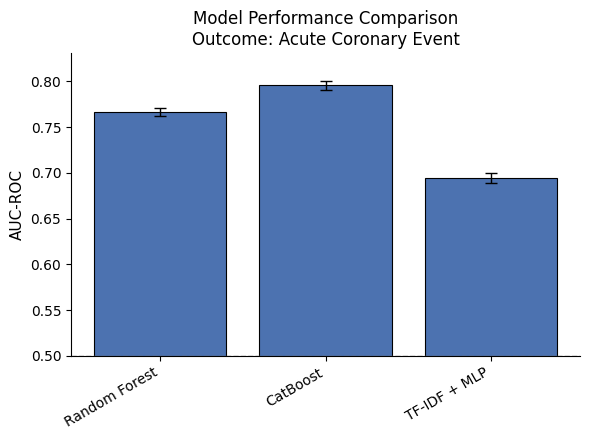

In [ ]:
#Datos
models = results_auc_outcome1["Model"]
means = results_auc_outcome1["AUC_mean"]
stds = results_auc_outcome1["AUC_std"]

plt.figure(figsize=(6, 4.5))

colors = ["#4C72B0"] * len(models)

bars = plt.bar(
    models,
    means,
    yerr=stds,
    capsize=4,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    error_kw=dict(
        elinewidth=1,
        ecolor="black",
        capthick=1
    )
)

#Línea de referencia AUC
plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    color="gray"
)

#Quitar bordes superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

#Ajustes de ejes
plt.ylabel("AUC-ROC", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0.5, max(means + stds) + 0.03)

# ¿Título estilo científico
plt.title(
    "Model Performance Comparison\nOutcome: Acute Coronary Event",
    fontsize=12
)

plt.tight_layout()
plt.savefig("auc_comparison_outcome1.pdf", bbox_inches="tight", facecolor="white")
plt.show()

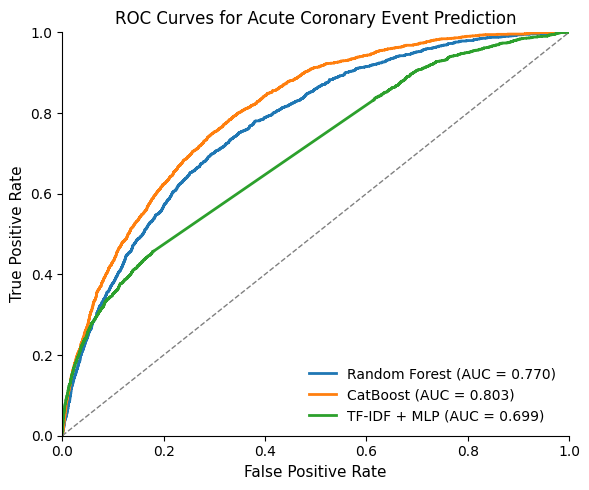

In [ ]:
#Calcular curvas ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, y_proba_rf)
fpr_cb, tpr_cb, _ = roc_curve(y_test_cb, y_proba_cb)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_mlp, y_proba_mlp)

auc_rf_val  = auc(fpr_rf, tpr_rf)
auc_cb_val  = auc(fpr_cb, tpr_cb)
auc_mlp_val = auc(fpr_mlp, tpr_mlp)

#Figura
plt.figure(figsize=(6, 5))

plt.plot(fpr_rf, tpr_rf, linewidth=2,
         label=f"Random Forest (AUC = {auc_rf_val:.3f})")

plt.plot(fpr_cb, tpr_cb, linewidth=2,
         label=f"CatBoost (AUC = {auc_cb_val:.3f})")

plt.plot(fpr_mlp, tpr_mlp, linewidth=2,
         label=f"TF-IDF + MLP (AUC = {auc_mlp_val:.3f})")

#Línea aleatoria
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)

#Estética
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curves for Acute Coronary Event Prediction", fontsize=12)

plt.legend(frameon=False, fontsize=10)
plt.xlim(0, 1)
plt.ylim(0, 1)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("roc_curves_outcome1.pdf", bbox_inches="tight", facecolor="white")
plt.show()

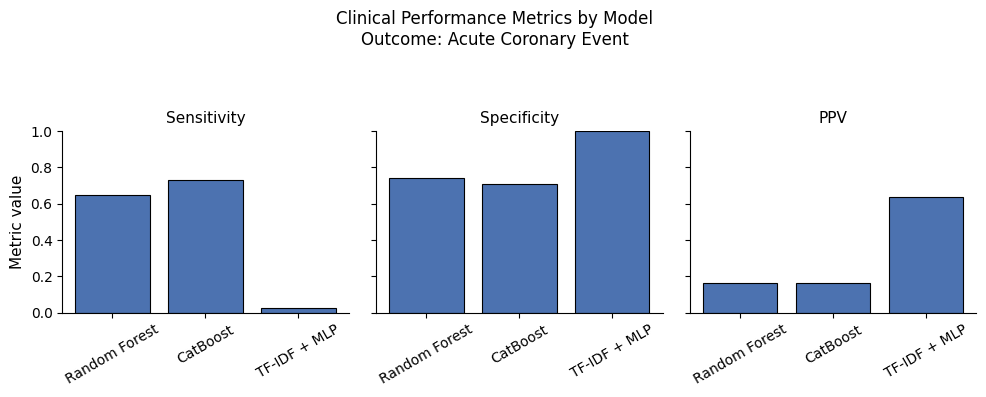

In [ ]:
#Modelos
models = ["Random Forest", "CatBoost", "TF-IDF + MLP"]

#Medias de métricas
sens_means = [
    np.mean(sens_rf),
    np.mean(sens_cb),
    np.mean(sens_mlp)
]

spec_means = [
    np.mean(spec_rf),
    np.mean(spec_cb),
    np.mean(spec_mlp)
]

ppv_means = [
    np.mean(ppv_rf),
    np.mean(ppv_cb),
    np.mean(ppv_mlp)
]

metrics = [
    ("Sensitivity", sens_means),
    ("Specificity", spec_means),
    ("PPV", ppv_means)
]

#Figura
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

for ax, (title, values) in zip(axes, metrics):
    ax.bar(
        models,
        values,
        color="#4C72B0",
        edgecolor="black",
        linewidth=0.8
    )
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)

    #Estilo limpio
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Metric value", fontsize=11)

plt.suptitle(
    "Clinical Performance Metrics by Model\nOutcome: Acute Coronary Event",
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("clinical_metrics_outcome1.pdf", bbox_inches="tight", facecolor="white")
plt.show()

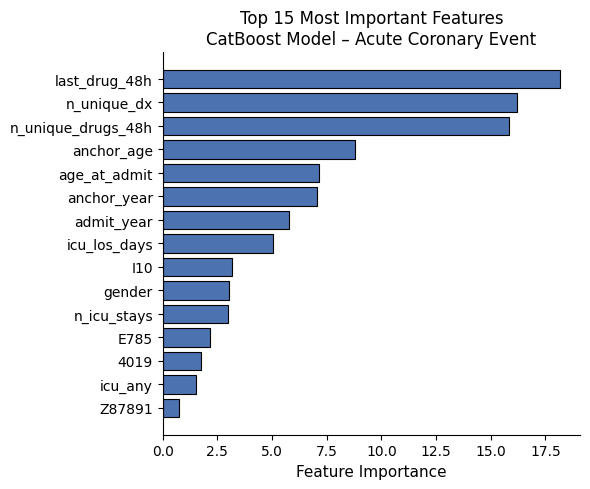

In [ ]:
#Obtener importancia de variables desde CatBoost
importances = cb_final.get_feature_importance()

fi_df = pd.DataFrame({
    "Feature": feature_names_cb,
    "Importance": importances
})

#Ordenar y seleccionar top 15
fi_df = fi_df.sort_values("Importance", ascending=False).head(15)

#Gráfico
plt.figure(figsize=(6, 5))

plt.barh(
    fi_df["Feature"][::-1],
    fi_df["Importance"][::-1],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.8
)

plt.xlabel("Feature Importance", fontsize=11)
plt.title(
    "Top 15 Most Important Features\nCatBoost Model – Acute Coronary Event",
    fontsize=12
)

#Dejar el gráfico limpio
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(
    "feature_importance_catboost_outcome1.pdf",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

# Gráficos de comparación - Mortalidad por evento coronario agudo

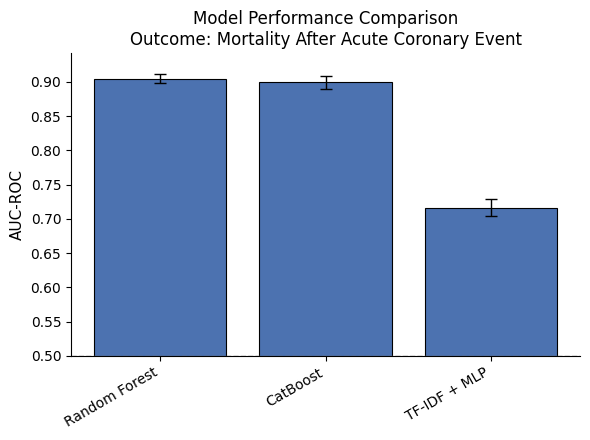

In [ ]:
results_auc_outcome2 = pd.DataFrame({
    "Model": [
        "Random Forest",
        "CatBoost",
        "TF-IDF + MLP"
    ],
    "AUC_mean": [
        np.mean(auc_rf_death),
        np.mean(auc_cb_death),
        np.mean(auc_mlp_death)
    ],
    "AUC_std": [
        np.std(auc_rf_death),
        np.std(auc_cb_death),
        np.std(auc_mlp_death)
    ]
})

#Datos
models = results_auc_outcome2["Model"]
means  = results_auc_outcome2["AUC_mean"]
stds   = results_auc_outcome2["AUC_std"]

plt.figure(figsize=(6, 4.5))

plt.bar(
    models,
    means,
    yerr=stds,
    capsize=4,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.8,
    error_kw=dict(elinewidth=1, ecolor="black", capthick=1)
)

plt.axhline(0.5, linestyle="--", linewidth=1, color="gray")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.ylabel("AUC-ROC", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0.5, max(means + stds) + 0.03)

plt.title(
    "Model Performance Comparison\nOutcome: Mortality After Acute Coronary Event",
    fontsize=12
)

plt.tight_layout()
plt.savefig("auc_comparison_outcome2.pdf", bbox_inches="tight", facecolor="white")
plt.show()

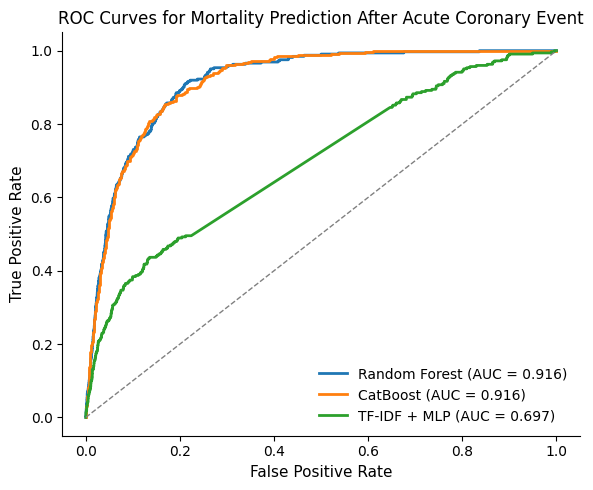

In [ ]:
fpr_rf, tpr_rf, _   = roc_curve(y_test_rf_death,  y_proba_rf_death)
fpr_cb, tpr_cb, _   = roc_curve(y_test_cb_death,  y_proba_cb_death)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_mlp_death, y_proba_mlp_death)

auc_rf_val  = auc(fpr_rf, tpr_rf)
auc_cb_val  = auc(fpr_cb, tpr_cb)
auc_mlp_val = auc(fpr_mlp, tpr_mlp)

plt.figure(figsize=(6, 5))

plt.plot(fpr_rf,  tpr_rf,  linewidth=2, label=f"Random Forest (AUC = {auc_rf_val:.3f})")
plt.plot(fpr_cb,  tpr_cb,  linewidth=2, label=f"CatBoost (AUC = {auc_cb_val:.3f})")
plt.plot(fpr_mlp, tpr_mlp, linewidth=2, label=f"TF-IDF + MLP (AUC = {auc_mlp_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)

plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curves for Mortality Prediction After Acute Coronary Event", fontsize=12)

plt.legend(frameon=False, fontsize=10, loc="lower right")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("roc_curves_outcome2.pdf", bbox_inches="tight", facecolor="white")
plt.show()

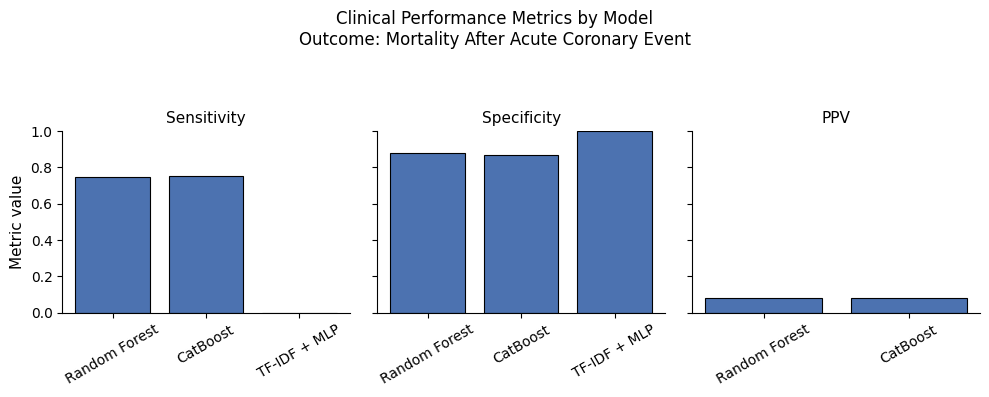

In [ ]:
models = ["Random Forest", "CatBoost", "TF-IDF + MLP"]

sens_means = [
    np.mean(sens_rf_death),
    np.mean(sens_cb_death),
    np.mean(sens_mlp_death)
]

spec_means = [
    np.mean(spec_rf_death),
    np.mean(spec_cb_death),
    np.mean(spec_mlp_death)
]

ppv_means = [
    np.mean(ppv_rf_death),
    np.mean(ppv_cb_death),
    np.mean(ppv_mlp_death)
]

metrics = [
    ("Sensitivity", sens_means),
    ("Specificity", spec_means),
    ("PPV", ppv_means)
]

fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

for ax, (title, values) in zip(axes, metrics):
    ax.bar(models, values, color="#4C72B0", edgecolor="black", linewidth=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Metric value", fontsize=11)

plt.suptitle(
    "Clinical Performance Metrics by Model\nOutcome: Mortality After Acute Coronary Event",
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("clinical_metrics_outcome2.pdf", bbox_inches="tight", facecolor="white")
plt.show()

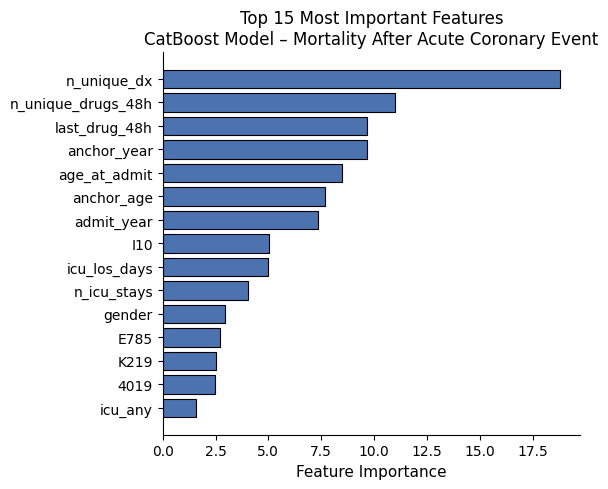

In [ ]:
#Importancia de variables desde CatBoost
importances = cb_final_death.get_feature_importance()

fi_df = pd.DataFrame({
    "Feature": feature_names_cb_death,
    "Importance": importances
})

#Top 15 variables más importantes
fi_df = (
    fi_df
    .sort_values("Importance", ascending=False)
    .head(15)
)

#Gráfico
plt.figure(figsize=(6, 5))

plt.barh(
    fi_df["Feature"][::-1],
    fi_df["Importance"][::-1],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.8
)

plt.xlabel("Feature Importance", fontsize=11)
plt.title(
    "Top 15 Most Important Features\nCatBoost Model – Mortality After Acute Coronary Event",
    fontsize=12
)

#Limpiar gráfico
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(
    "feature_importance_catboost_outcome2.pdf",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()